<a href="https://colab.research.google.com/github/rg5139/GamerPsycheAnalytics/blob/main/GMM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

# =========================
# 0) Load
# =========================
gamers_csv = pd.read_csv("/content/cleaned_gamers_dataset.csv").copy()

print("Rows, Cols:", gamers_csv.shape)
print("Nulls (top 15):")
print(gamers_csv.isna().sum().sort_values(ascending=False).head(15))




Rows, Cols: (13407, 80)
Nulls (top 15):
Degree_original             1571
Degree                      1571
GADE                         647
earnings_subcluster          314
Birthplace_ISO3              120
Birthplace_ISO3_ISO3         120
Birthplace_ISO3_Numeric      120
Birthplace_ISO3_original     120
Residence_ISO3               109
Residence_ISO3_ISO3          109
Residence_ISO3_original      109
Residence_ISO3_Numeric       109
Hours                         30
GAD4                           0
S. No.                         0
dtype: int64


In [43]:
clustering_features = [
    'Hours',
    'streams',
    'Playstyle_enum',
    'whyplay_winning',
    'whyplay_improving',
    'whyplay_relaxing',
    'whyplay_having_fun',
    'whyplay_combined',
    'whyplay_novel'
]

gamers_csv[clustering_features] = gamers_csv[clustering_features].apply(
    pd.to_numeric, errors='coerce'
)

# ------------------------------------------------------------
# Step 3: Create the feature matrix and remove rows with
# missing values in any clustering feature.
# ------------------------------------------------------------
X = gamers_csv[clustering_features].copy()
X.dropna(inplace=True)

# Store indices of rows retained for clustering
kept_indices = X.index

# ------------------------------------------------------------
# Step 4: Standardize features
# Standardization is required because K-means relies on
# Euclidean distance, and variables are on different scales.
# ------------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [44]:
X.shape

(13377, 9)

In [45]:
k = 4
kmeans = KMeans(
    n_clusters=k,
    n_init=50,
    random_state=42,
    init='k-means++'
)

kmeans_labels = kmeans.fit_predict(X_scaled)


gmm = GaussianMixture(
    n_components=4,
    covariance_type='full',
    random_state=42,
    n_init=10
)

gmm_labels = gmm.fit_predict(X_scaled)

In [46]:
pd.crosstab(kmeans_labels, gmm_labels)

col_0,0,1,2,3
row_0,,,,
0,5527,0,0,0
1,1,4968,0,0
2,0,0,2191,0
3,0,0,0,690


In [47]:
bic = []
for k in range(2,7):
    gmm = GaussianMixture(n_components=k, covariance_type='full')
    gmm.fit(X_scaled)
    bic.append(gmm.bic(X_scaled))

In [48]:
bic

[np.float64(-245866.8925454508),
 np.float64(-600058.3405397964),
 np.float64(-785139.4030336132),
 np.float64(-843567.7896609771),
 np.float64(-853337.8950158426)]

In [49]:
probs = gmm.predict_proba(X_scaled)
max_probs = probs.max(axis=1)

In [50]:
np.mean(max_probs)

np.float64(1.0)

In [51]:
for cov in ['full','tied','diag','spherical']:
    gmm = GaussianMixture(n_components=4, covariance_type=cov)
    gmm.fit(X_scaled)
    print(cov, gmm.bic(X_scaled))

full -597618.1193469942
tied -388314.5710954346
diag -756620.5483214449
spherical 192004.05718671784


Text(0, 0.5, 'Principal Component 2')

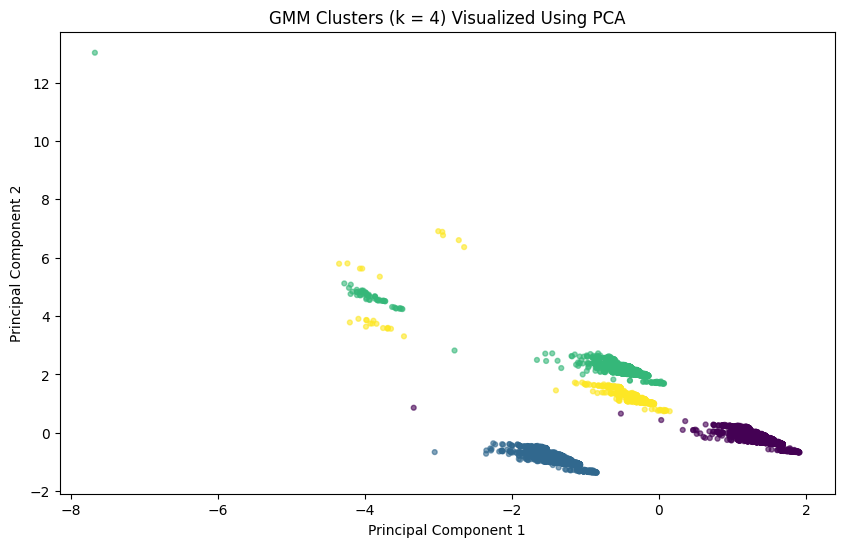

In [52]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=gmm_labels,
    cmap='viridis',
    s=12,
    alpha=0.6
)
plt.title('GMM Clusters (k = 4) Visualized Using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

In [53]:
gamers_csv['GMM_Cluster'] = np.nan
gamers_csv.loc[kept_indices, 'GMM_Cluster'] = gmm_labels

gamers_csv.groupby('GMM_Cluster')[[
    'GAD_T','SWL_T','SPIN_T_imputed'
]].mean()

,GAD_T,SWL_T,SPIN_T_imputed
GMM_Cluster,,,
0.0,4.674023,20.584660,19.341172
1.0,5.265499,19.627818,19.487721
2.0,6.115929,18.398448,21.900046
3.0,6.200000,19.030435,20.192754


In [54]:
from scipy.stats import f_oneway

f_oneway(
    gamers_csv[gamers_csv.GMM_Cluster==0]['GAD_T'],
    gamers_csv[gamers_csv.GMM_Cluster==1]['GAD_T'],
    gamers_csv[gamers_csv.GMM_Cluster==2]['GAD_T'],
    gamers_csv[gamers_csv.GMM_Cluster==3]['GAD_T']
)

F_onewayResult(statistic=np.float64(62.166441788073655), pvalue=np.float64(6.585423642351162e-40))

In [55]:
from sklearn.metrics import adjusted_rand_score

adjusted_rand_score(kmeans_labels, gmm_labels)

0.999737916937101